Task A. Data Processing and Graph Construction

In [3]:
import networkx as nx
import math
import random
import pandas as pd


def load_graph(edge_file):
    G = nx.read_edgelist(edge_file, nodetype=int)
    return G

def shortest_path_feature(G, u, v, max_distance=4):
    try:
        dist = nx.shortest_path_length(G, u, v)
        if dist <= max_distance and dist > 0:
            return 1 / dist
        else:
            return 0
    except nx.NetworkXNoPath:
        return 0

def compute_features(G, u, v):
    common_neighbors = len(list(nx.common_neighbors(G, u, v)))
    union = len(set(G.neighbors(u)).union(G.neighbors(v)))
    jaccard = common_neighbors / union if union != 0 else 0

    try:
        admic_adda = sum(1 / math.log(G.degree(w)) for w in nx.common_neighbors(G, u, v))
    except ZeroDivisionError:
        admic_adda = 0

    resource_allocation = sum(1 / G.degree(w) for w in nx.common_neighbors(G, u, v) if G.degree(w) > 0)

    preferential_attachment = G.degree(u) * G.degree(v)

    return [common_neighbors, jaccard, admic_adda, resource_allocation, preferential_attachment]

G_train = load_graph('../ASTRO-PH/CA-AstroPh-train.txt')
print("Nodes:", G_train.number_of_nodes())
print("Edges:", G_train.number_of_edges())

Nodes: 18616
Edges: 178443


In [4]:
G_test = load_graph('../ASTRO-PH/CA-AstroPh-test.txt')
print("Nodes:", G_test.number_of_nodes())
print("Edges:", G_test.number_of_edges())


Nodes: 11517
Edges: 19667


In [5]:
# treat all edges as undirected and remove duplicated edges
G_train = G_train.to_undirected()
G_test = G_test.to_undirected()

In [6]:
# remove self-loops
# print the number of self-loops removed
print("Removed self-loops in train set:", len(list(nx.selfloop_edges(G_train))))
print("Removed self-loops in test set:", len(list(nx.selfloop_edges(G_test))))
G_train.remove_edges_from(nx.selfloop_edges(G_train))
G_test.remove_edges_from(nx.selfloop_edges(G_test))

Removed self-loops in train set: 56
Removed self-loops in test set: 4


In [38]:
# Identify overlapping edges of the combined train and test sets
overlap_edges = set(G_train.edges()).intersection(set(G_test.edges()))
print("Number of overlapping edges:", len(overlap_edges))

Number of overlapping edges: 0


In [7]:
# identify future edges, meaning edges that do not appear in train but do appear in test 
future_edges = set(G_test.edges()) - set(G_train.edges())
print("Number of future edges:", len(future_edges))

Number of future edges: 19663


In [40]:
# print future edges
print("Future edges (first 10):", list(future_edges)[:10])

Future edges (first 10): [(82587, 75612), (64909, 7264), (130561, 3907), (22105, 74844), (48487, 88012), (110392, 74290), (60288, 53483), (108108, 124668), (90879, 94797), (115543, 57091)]


Task B. Network Analysis

,Graph,Number of Nodes,Number of Edges,Average Degree,Maximum Degree,Graph Density,Connected Components,Average Clustering Coefficient
0,Train,18616,178387,19.1649,461,0.001030,282,0.551517
1,Test,11517,19663,3.4146,49,0.000297,730,0.032197


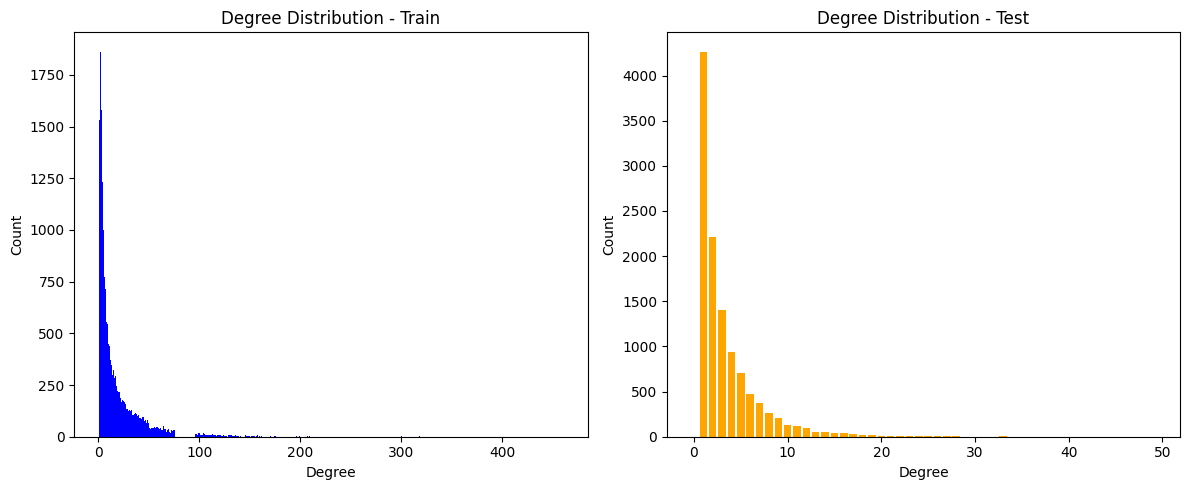

In [41]:
import pandas as pd
import networkx as nx
from IPython.display import display

def graph_statistics(G, graph_name):
    degrees = dict(G.degree())
    degree_values = list(degrees.values())
    avg_degree = sum(degree_values) / len(degree_values) if degree_values else 0
    max_degree = max(degree_values) if degree_values else 0
    density = nx.density(G)
    num_components = nx.number_connected_components(G)
    avg_clustering = nx.average_clustering(G)
    degree_distribution = pd.Series(degree_values).value_counts().sort_index()

    summary = pd.DataFrame([{
        "Graph": graph_name,
        "Number of Nodes": G.number_of_nodes(),
        "Number of Edges": G.number_of_edges(),
        "Average Degree": round(avg_degree, 4),
        "Maximum Degree": max_degree,
        "Graph Density": round(density, 6),
        "Connected Components": num_components,
        "Average Clustering Coefficient": round(avg_clustering, 6),
    }])

    distribution = degree_distribution.reset_index()
    distribution.columns = ["Degree", "Count"]

    return summary, distribution

train_summary, train_degree_distribution = graph_statistics(G_train, "Train")
test_summary, test_degree_distribution = graph_statistics(G_test, "Test")

graph_summary_table = pd.concat([train_summary, test_summary], ignore_index=True)
display(graph_summary_table)

#show the bar chart of degree distribution for train and test sets
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(train_degree_distribution["Degree"], train_degree_distribution["Count"], color='blue')
plt.title("Degree Distribution - Train")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.subplot(1, 2, 2)

plt.bar(test_degree_distribution["Degree"], test_degree_distribution["Count"], color='orange')
plt.title("Degree Distribution - Test")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [42]:
def add_samples(G, pairs, label, X, y):
    for u, v in pairs:
        features = compute_features(G, u, v)
        X.append([u, v, *features])
        y.append(label)

def create_dataset(G, num_negative=None):
    edges = list(G.edges())
    non_edges = list(nx.non_edges(G))

    if num_negative is None:
        num_negative = len(edges)

    non_edges = random.sample(non_edges, num_negative)

    # X = [ (u, v, features) for (u, v) in edges + non_edges ]
    X = []
    y = []

    # Positive links (edges that exist)
    add_samples(G, edges, label=1, X=X, y=y)

    # Negative links (non-edges)
    add_samples(G, non_edges, label=0, X=X, y=y)


    return pd.DataFrame(X), pd.Series(y)

X, y = create_dataset(G_train)

#label the header of X with the feature names
X.columns = ["u", "v", "common_neighbors", "jaccard", "admic_adda", "resource_allocation", "preferential_attachment"]

# store X and y in the same csv file for later use
train_data = pd.concat([X, y.rename("label")], axis=1)
train_data.to_csv("train_data.csv", index=False)

In [8]:
import numpy as np
from scipy.optimize import fmin_l_bfgs_b


class SupervisedRandomWalk:
    def __init__(self, alpha=0.15, b=0.1, reg_lambda=1.0, max_iter=200, tol=1e-10):
        self.alpha = float(alpha)
        self.b = float(b)
        self.reg_lambda = float(reg_lambda)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.w = None
        self.opt_info = None

    @staticmethod
    def _sigmoid(x):
        x = np.clip(x, -50.0, 50.0)
        return 1.0 / (1.0 + np.exp(-x))

    def _validate_inputs(self, G_features, source_idx):
        if G_features.ndim != 3:
            raise ValueError("G_features must have shape (n_nodes, n_nodes, n_features).")

        n, m, k = G_features.shape
        if n != m:
            raise ValueError("G_features must be square on the first two axes.")
        if k == 0:
            raise ValueError("G_features must contain at least one feature per edge.")
        if not (0 <= source_idx < n):
            raise ValueError("source_idx is out of range.")

    def _compute_transition_matrix(self, G_features, w, source_idx):
        n = G_features.shape[0]
        edge_mask = np.any(np.abs(G_features) > 0, axis=2)

        logits = np.tensordot(G_features, w, axes=([2], [0]))
        strengths = self._sigmoid(logits) * edge_mask
        d_strengths_dw = (strengths * (1.0 - strengths))[..., None] * G_features

        row_sums = strengths.sum(axis=1, keepdims=True)
        Q_prime = np.divide(
            strengths,
            row_sums,
            out=np.zeros_like(strengths),
            where=row_sums > 0,
        )

        # Dangling rows: force all probability to restart source before alpha mixing.
        dangling_rows = row_sums[:, 0] <= 0
        if np.any(dangling_rows):
            Q_prime[dangling_rows, :] = 0.0
            Q_prime[dangling_rows, source_idx] = 1.0

        dz_dw = d_strengths_dw.sum(axis=1)
        denom = row_sums[..., None] ** 2
        dQ_prime_dw = np.divide(
            d_strengths_dw * row_sums[..., None] - strengths[..., None] * dz_dw[:, None, :],
            denom,
            out=np.zeros_like(d_strengths_dw),
            where=denom > 0,
        )

        if np.any(dangling_rows):
            dQ_prime_dw[dangling_rows, :, :] = 0.0

        Q = (1.0 - self.alpha) * Q_prime
        Q[:, source_idx] += self.alpha

        dQ_dw = (1.0 - self.alpha) * np.transpose(dQ_prime_dw, (2, 0, 1))
        return Q, dQ_dw

    def algorithm_1(self, Q, dQ_dw, source_idx):
        n = Q.shape[0]
        k = dQ_dw.shape[0]

        # Start from restart distribution concentrated on the source.
        p = np.zeros(n)
        p[source_idx] = 1.0

        for _ in range(self.max_iter):
            p_new = p @ Q
            if np.linalg.norm(p_new - p, ord=1) < self.tol:
                p = p_new
                break
            p = p_new

        dp_dw = np.zeros((k, n))
        for _ in range(self.max_iter):
            dp_next = dp_dw @ Q + np.einsum("j,kjn->kn", p, dQ_dw)
            if np.linalg.norm(dp_next - dp_dw, ord=1) < self.tol:
                dp_dw = dp_next
                break
            dp_dw = dp_next

        return p, dp_dw

    def wmw_loss(self, w, G_features, source_idx, D_indices, L_indices):
        Q, dQ_dw = self._compute_transition_matrix(G_features, w, source_idx)
        p, dp_dw = self.algorithm_1(Q, dQ_dw, source_idx)

        l2 = np.dot(w, w)
        loss = self.reg_lambda * l2
        gradient = 2.0 * self.reg_lambda * w

        if len(D_indices) == 0 or len(L_indices) == 0:
            return float(loss), gradient

        for d in D_indices:
            for l in L_indices:
                diff = (p[l] - p[d]) / self.b
                sigma = self._sigmoid(diff)
                loss += sigma

                dsigma_ddiff = sigma * (1.0 - sigma)
                gradient += (dsigma_ddiff / self.b) * (dp_dw[:, l] - dp_dw[:, d])

        return float(loss), gradient

    def fit(self, G_features, source_idx, D_indices, L_indices, initial_w=None, maxfun=150):
        self._validate_inputs(G_features, source_idx)

        n_features = G_features.shape[-1]
        if initial_w is None:
            initial_w = np.zeros(n_features, dtype=float)
        else:
            initial_w = np.asarray(initial_w, dtype=float)
            if initial_w.shape != (n_features,):
                raise ValueError("initial_w must have shape (n_features,).")

        D_indices = np.asarray(D_indices, dtype=int)
        L_indices = np.asarray(L_indices, dtype=int)

        self.w, fval, info = fmin_l_bfgs_b(
            self.wmw_loss,
            initial_w,
            args=(G_features, source_idx, D_indices, L_indices),
            maxfun=maxfun,
        )

        self.opt_info = {
            "final_loss": float(fval),
            "optimizer_info": info,
        }
        return self

    def predict_scores(self, G_features, source_idx):
        if self.w is None:
            raise ValueError("Model is not fitted. Call fit(...) first.")
        self._validate_inputs(G_features, source_idx)
        Q, dQ_dw = self._compute_transition_matrix(G_features, self.w, source_idx)
        p, _ = self.algorithm_1(Q, dQ_dw, source_idx)
        return p

Task C. Supervised Random Walk End-to-End Example
This example builds edge-feature tensors on a local subgraph, trains SRW for one source node, and evaluates ranking quality on future links.

In [14]:
from sklearn.metrics import roc_auc_score

# ------------------------------
# 1) Candidate graph construction
# ------------------------------
def local_subgraph_nodes(G, source, depth=2, max_nodes=120):
    # Build a local neighborhood around the source to keep SRW training efficient.
    visited = {source}
    frontier = {source}

    for _ in range(depth):
        next_frontier = set()
        for u in frontier:
            next_frontier.update(G.neighbors(u))

        next_frontier -= visited
        if not next_frontier:
            break

        capacity = max_nodes - len(visited)
        if capacity <= 0:
            break

        # Cap node count to avoid large transition matrices.
        if len(next_frontier) > capacity:
            next_frontier = set(list(next_frontier)[:capacity])

        visited.update(next_frontier)
        frontier = next_frontier

    return list(visited)


def future_positive_nodes_for_source(future_edges, source_node, node_set):
    # Supervision target: nodes that become connected to source in the future graph.
    positives = set()
    for u, v in future_edges:
        if u == source_node and v in node_set:
            positives.add(v)
        elif v == source_node and u in node_set:
            positives.add(u)
    return positives


def pick_source_with_local_positives(
    G_train,
    future_edges,
    min_global_pos=2,
    min_local_pos=2,
    depth=2,
    max_nodes=120,
    max_candidates=200,
):
    # Choose a source node that has enough positive examples for supervised learning.
    counts = {}
    for u, v in future_edges:
        counts[u] = counts.get(u, 0) + 1
        counts[v] = counts.get(v, 0) + 1

    if not counts:
        raise ValueError("No future edges available to build a supervised task.")

    candidates = sorted(
        [node for node, c in counts.items() if c >= min_global_pos],
        key=lambda x: counts[x],
        reverse=True,
    )

    if not candidates:
        candidates = sorted(counts.keys(), key=lambda x: counts[x], reverse=True)

    for source_node in candidates[:max_candidates]:
        nodes = local_subgraph_nodes(G_train, source_node, depth=depth, max_nodes=max_nodes)
        positives = future_positive_nodes_for_source(future_edges, source_node, set(nodes))
        if len(positives) >= min_local_pos:
            return source_node, nodes, positives

    raise ValueError("Could not find a source node with enough local positive future links.")


def build_edge_feature_tensor(G_base, nodes):
    # Build SRW edge-feature tensor: shape (n_nodes, n_nodes, n_features).
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)
    k = 6  # [bias, common_neighbors, jaccard, adamic_adar, resource_allocation, pref_attachment]
    G_features = np.zeros((n, n, k), dtype=float)

    for u, v in G_base.subgraph(nodes).edges():
        i = node_to_idx[u]
        j = node_to_idx[v]
        common, jaccard, adamic, ra, pref = compute_features(G_base, u, v)
        feat = np.array([1.0, common, jaccard, adamic, ra, pref], dtype=float)

        # Undirected graph: assign identical features in both directions.
        G_features[i, j] = feat
        G_features[j, i] = feat

    return G_features, node_to_idx


def build_train_eval_indices(G_train, source_node, nodes, node_to_idx, positives, max_neg=40):
    # Build pairwise supervision sets: D = positives, L = sampled negatives.
    train_neighbors = set(G_train.neighbors(source_node))
    candidate_neg = [
        node for node in nodes
        if node != source_node and node not in positives and node not in train_neighbors
    ]

    if not candidate_neg:
        raise ValueError("No negative candidates found for the selected source.")

    rng = np.random.default_rng(42)
    neg_size = min(len(candidate_neg), max_neg, max(2, len(positives) * 2))
    negatives = list(rng.choice(candidate_neg, size=neg_size, replace=False))

    D_indices = np.array([node_to_idx[p] for p in positives], dtype=int)
    L_indices = np.array([node_to_idx[n] for n in negatives], dtype=int)
    return D_indices, L_indices, negatives


# ------------------------------
# 2) Build supervised SRW training data
# ------------------------------
source_node, nodes, positives = pick_source_with_local_positives(
    G_train,
    future_edges,
    min_global_pos=2,
    min_local_pos=2,
    depth=2,
    max_nodes=120,
)

G_features, node_to_idx = build_edge_feature_tensor(G_train, nodes)
source_idx = node_to_idx[source_node]

D_indices, L_indices, negatives = build_train_eval_indices(
    G_train, source_node, nodes, node_to_idx, positives
)

# ------------------------------
# 3) Train SRW model (learn edge-feature weights)
# ------------------------------
model = SupervisedRandomWalk(alpha=0.15, b=0.1, reg_lambda=0.01, max_iter=120, tol=1e-9)
model.fit(G_features, source_idx, D_indices, L_indices, maxfun=120)

# ------------------------------
# 4) Infer personalized ranking scores from trained SRW
# ------------------------------
scores = model.predict_scores(G_features, source_idx)

# ------------------------------
# 5) Evaluate ranking quality on unseen future links
# ------------------------------
# Evaluate only on candidate nodes not already connected in train graph.
train_neighbors = set(G_train.neighbors(source_node))
eval_nodes = [
    node for node in nodes
    if node != source_node and node not in train_neighbors
]

# Label is 1 if node becomes a future neighbor of source.
y_true = np.array([1 if node in positives else 0 for node in eval_nodes], dtype=int)
y_score = np.array([scores[node_to_idx[node]] for node in eval_nodes], dtype=float)

auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else np.nan

ranking = sorted(
    [(node, scores[node_to_idx[node]], int(node in positives)) for node in eval_nodes],
    key=lambda x: x[1],
    reverse=True,
)

# ------------------------------
# 6) Report results
# ------------------------------
print(f"Source node: {source_node}")
print(f"Local subgraph nodes: {len(nodes)}")
print(f"Positive future links in local graph: {len(positives)}")
print(f"Negative training nodes: {len(negatives)}")
print(f"AUC on local candidate ranking: {auc:.4f}")
print("Top-10 recommended nodes: (node_id, score, is_future_link)")
for row in ranking[:10]:
    print(row)

print("Learned weight vector:")
print(model.w)
print("Optimizer summary keys:", list(model.opt_info["optimizer_info"].keys()))

Source node: 124956
Local subgraph nodes: 120
Positive future links in local graph: 2
Negative training nodes: 4
AUC on local candidate ranking: 0.9500
Top-10 recommended nodes: (node_id, score, is_future_link)
(90186, 0.009340690037404068, 1)
(40978, 0.0070379810362631925, 0)
(106497, 0.006535733058900201, 0)
(49236, 0.006313470143810195, 0)
(16434, 0.004677630428849194, 1)
(114715, 0.003290096055375541, 0)
(82009, 0.0026678738757938566, 0)
(30, 0.0026046360161461712, 0)
(98354, 0.0018841659217663418, 0)
(41058, 0.0017699811637072469, 0)
Learned weight vector:
[-0.00591364 -0.11508242 -0.00238948 -0.03089899 -0.00295864  0.00022918]
Optimizer summary keys: ['grad', 'task', 'funcalls', 'nit', 'warnflag']


How to Improve Supervised Random Walk Results
1. Use more source nodes: train/evaluate across many source nodes and report mean AUC to reduce variance from one-node results.
2. Increase training positives: require more local future links per source (for example at least 5) before training.
3. Better negative sampling: use hard negatives (2-hop nodes or high-common-neighbor nodes) instead of only random negatives.
4. Add richer edge features: include shortest-path-based features, temporal recency, node centrality, and embedding similarity (e.g., node2vec cosine).
5. Feature scaling: normalize each feature (z-score or min-max) before optimization to stabilize gradients.
6. Hyperparameter search: tune alpha, b, reg_lambda, max_iter, and maxfun with validation splits.
7. Larger local graph: increase depth/max_nodes carefully so SRW sees more candidate nodes without making matrices too large.
8. Robust evaluation: use multiple train/validation/test temporal splits and report AUC plus Precision@k/Recall@k.
9. Early stopping and convergence checks: tighten tolerance and verify optimizer convergence flags.
10. Ensemble approach: combine SRW scores with heuristics (Adamic-Adar, Resource Allocation, Preferential Attachment) using a meta-model.

Task D. Machine Learning Models (Alternative to SRW)
This is a separate block that applies standard supervised ML classifiers for link prediction using the same local-graph setup.

In [17]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


def build_pair_features_for_source_ml(G_train, source_node, candidate_nodes):
    rows = []
    for v in candidate_nodes:
        common, jaccard, adamic, ra, pref = compute_features(G_train, source_node, v)
        rows.append([common, jaccard, adamic, ra, pref])
    return np.array(rows, dtype=float)


# Reuse Task C helper to pick a valid source for supervised learning.
source_node_ml, nodes_ml, positives_ml = pick_source_with_local_positives(
    G_train,
    future_edges,
    min_global_pos=2,
    min_local_pos=2,
    depth=2,
    max_nodes=120,
)

train_neighbors_ml = set(G_train.neighbors(source_node_ml))
candidate_nodes_ml = [
    node for node in nodes_ml
    if node != source_node_ml and node not in train_neighbors_ml
]

X_ml = build_pair_features_for_source_ml(G_train, source_node_ml, candidate_nodes_ml)
y_ml = np.array([1 if node in positives_ml else 0 for node in candidate_nodes_ml], dtype=int)

if len(np.unique(y_ml)) < 2:
    raise ValueError("Not enough class diversity for ML training.")

X_train_ml, X_test_ml, y_train_ml, y_test_ml, nodes_train_ml, nodes_test_ml = train_test_split(
    X_ml,
    y_ml,
    candidate_nodes_ml,
    test_size=0.4,
    random_state=42,
    stratify=y_ml,
    shuffle=True,
    )

models_ml = {
    "LogisticRegression": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
            ),
        ]
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

results_ml = []
fitted_models_ml = {}

for name, clf in models_ml.items():
    clf.fit(X_train_ml, y_train_ml)
    y_prob_ml = clf.predict_proba(X_test_ml)[:, 1]
    auc_ml = roc_auc_score(y_test_ml, y_prob_ml)
    ap_ml = average_precision_score(y_test_ml, y_prob_ml)
    results_ml.append((name, auc_ml, ap_ml))
    fitted_models_ml[name] = clf

results_ml = sorted(results_ml, key=lambda x: x[1], reverse=True)
best_model_name_ml = results_ml[0][0]
best_model_ml = fitted_models_ml[best_model_name_ml]

all_scores_ml = best_model_ml.predict_proba(X_ml)[:, 1]
ranking_ml = sorted(
    [(node, score, int(label)) for node, score, label in zip(candidate_nodes_ml, all_scores_ml, y_ml)],
    key=lambda x: x[1],
    reverse=True,
)

print(f"Source node (ML): {source_node_ml}")
print(f"Local subgraph nodes (ML): {len(nodes_ml)}")
print(f"Candidate nodes (ML): {len(candidate_nodes_ml)}")
print(f"Positive future links (ML): {int(y_ml.sum())}")
print("\nModel comparison (sorted by AUC):")
for name, auc_ml, ap_ml in results_ml:
    print(f"{name}: AUC={auc_ml:.4f}, AP={ap_ml:.4f}")

print(f"\nBest ML model: {best_model_name_ml}")
print("Top-10 ML recommendations: (node_id, score, is_future_link)")
for row in ranking_ml[:10]:
    print(row)

Source node (ML): 124956
Local subgraph nodes (ML): 120
Candidate nodes (ML): 32
Positive future links (ML): 2

Model comparison (sorted by AUC):
LogisticRegression: AUC=1.0000, AP=1.0000
RandomForest: AUC=1.0000, AP=1.0000
GradientBoosting: AUC=1.0000, AP=1.0000

Best ML model: LogisticRegression
Top-10 ML recommendations: (node_id, score, is_future_link)
(90186, 0.999999931509947, 1)
(16434, 0.983597161318846, 1)
(98354, 0.0560809389587258, 0)
(40978, 0.050230377823722805, 0)
(49236, 0.049458433471537964, 0)
(40990, 0.026548836823609874, 0)
(106497, 0.025275747473854995, 0)
(30, 0.021846882988512287, 0)
(114715, 0.015258782972286637, 0)
(16400, 0.014091348140533968, 0)



Comparison of SRW and ML top-8 unlink recommendations:
     Node  SRW Score  ML Score  Is Future Link
0   40978   0.007038  0.050230               0
1  106497   0.006536  0.025276               0
2   49236   0.006313  0.049458               0
3  114715   0.003290  0.015259               0
4   82009   0.002668  0.006377               0
5      30   0.002605  0.021847               0
6   98354   0.001884  0.056081               0
7   41058   0.001770  0.008943               0


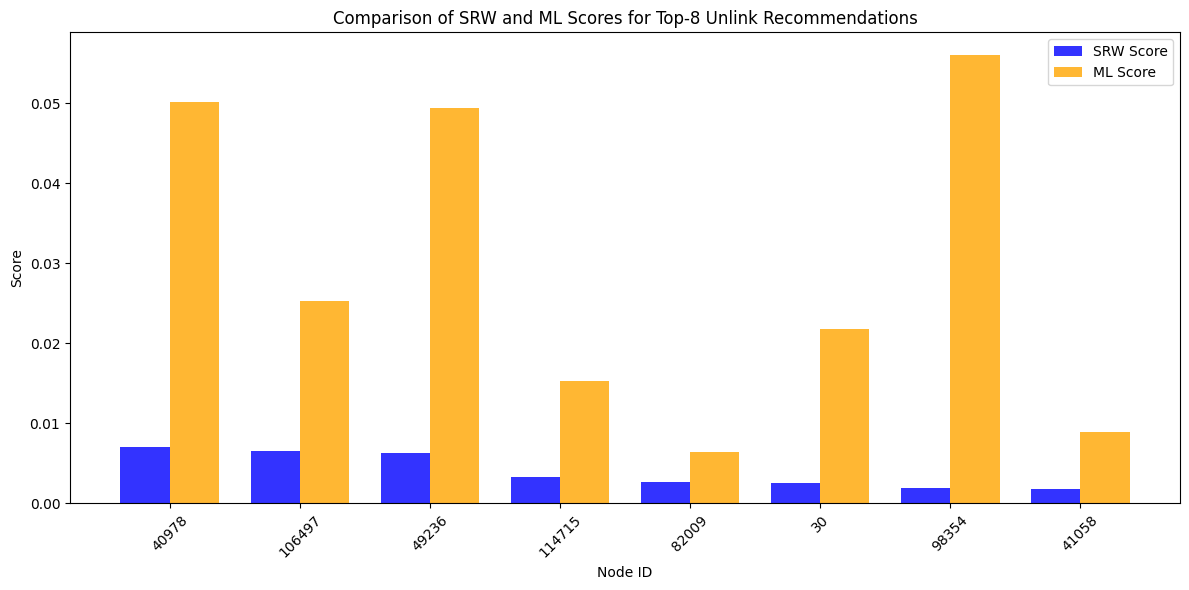

In [24]:
# draw the chart and the table compare the SRW and ML results
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Build a node->score lookup because ranking_ml stores tuples (node, score, label).
ml_score_map = {node: score for node, score, _ in ranking_ml}

# Prepare data for comparison
comparison_data = []

# Remove is future link = 1 for nodes that are not in the future edges, to make it more clear in the table
for node, score, is_future in ranking[:10]:
    if is_future == 0:
        comparison_data.append({
            "Node": node,
            "SRW Score": score,
            "ML Score": ml_score_map.get(node, float("nan")),
            "Is Future Link": is_future
        })

comparison_df = pd.DataFrame(comparison_data)
print("\nComparison of SRW and ML top-8 unlink recommendations:")
print(comparison_df)

# Side-by-side bar chart comparison
x = np.arange(len(comparison_df))
width = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, comparison_df["SRW Score"], width=width, alpha=0.8, label="SRW Score", color="blue")
plt.bar(x + width / 2, comparison_df["ML Score"], width=width, alpha=0.8, label="ML Score", color="orange")

plt.xlabel("Node ID")
plt.ylabel("Score")
plt.title("Comparison of SRW and ML Scores for Top-8 Unlink Recommendations")
plt.xticks(x, comparison_df["Node"].astype(str), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

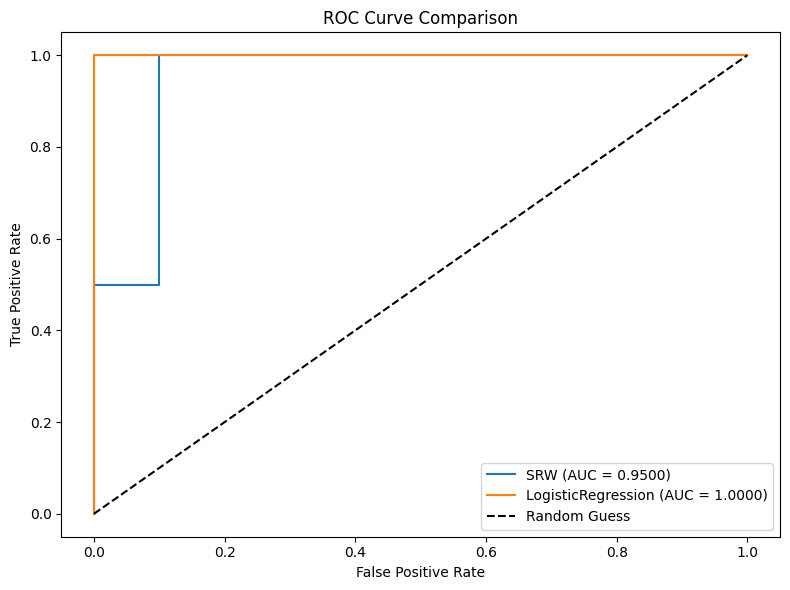

In [29]:
# Compare the AUC of ML models and SRW in ROC curve
from sklearn.metrics import roc_curve, auc
def plot_roc_curve(y_true, y_scores, label):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.4f})")
    return roc_auc
plt.figure(figsize=(8, 6))
auc_srw = plot_roc_curve(y_true, y_score, "SRW")
auc_ml = plot_roc_curve(y_test_ml, y_prob_ml, best_model_name_ml)
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()